# Loading Libraries

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset

In [86]:
df = pd.read_excel("Freelance_data.xlsx")
df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L
...,...,...,...,...,...,...,...,...,...,...,...
602,2022,SE,FT,Data Engineer,154000,USD,154000,US,100,US,M
603,2022,SE,FT,Data Engineer,126000,USD,126000,US,100,US,M
604,2022,SE,FT,Data Analyst,129000,USD,129000,US,0,US,M
605,2022,SE,FT,Data Analyst,150000,USD,150000,US,100,US,M


# Descriptive Statistics

In [87]:
df.shape

(607, 11)

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           607 non-null    int64 
 1   experience_level    607 non-null    object
 2   employment_type     607 non-null    object
 3   job_title           607 non-null    object
 4   salary              607 non-null    int64 
 5   salary_currency     607 non-null    object
 6   salary_in_usd       607 non-null    int64 
 7   employee_residence  607 non-null    object
 8   remote_ratio        607 non-null    int64 
 9   company_location    607 non-null    object
 10  company_size        607 non-null    object
dtypes: int64(4), object(7)
memory usage: 52.3+ KB


In [89]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,6.070000e+02,607.000000,607.00000
mean,2021.405272,3.240001e+05,112297.869852,70.92257
std,0.692133,1.544357e+06,70957.259411,40.70913
min,2020.000000,4.000000e+03,2859.000000,0.00000
25%,2021.000000,7.000000e+04,62726.000000,50.00000
50%,2022.000000,1.150000e+05,101570.000000,100.00000
75%,2022.000000,1.650000e+05,150000.000000,100.00000
max,2022.000000,3.040000e+07,600000.000000,100.00000


# Business Decision

## First Moment Business Decision

In [90]:
for col in df.select_dtypes(include="number").columns:
    print(f'Mean of {col}: {df[col].mean()}')
    print(f'Median of {col}: {df[col].median()}')
    print(f'Mode of {col}: {df[col].mode()}')

Mean of work_year: 2021.4052718286655
Median of work_year: 2022.0
Mode of work_year: 0    2022
Name: work_year, dtype: int64
Mean of salary: 324000.0626029654
Median of salary: 115000.0
Mode of salary: 0     80000
1    100000
Name: salary, dtype: int64
Mean of salary_in_usd: 112297.86985172982
Median of salary_in_usd: 101570.0
Mode of salary_in_usd: 0    100000
Name: salary_in_usd, dtype: int64
Mean of remote_ratio: 70.92257001647447
Median of remote_ratio: 100.0
Mode of remote_ratio: 0    100
Name: remote_ratio, dtype: int64


## Second Moment Business Decision

In [91]:
for col in df.select_dtypes(include="number").columns:
    print(f'Standard Deviation of {col}: {df[col].std()}')
    print(f'Variance of {col}: {df[col].var()}')
    print(f'Range of {col}: {df[col].max() - df[col].min()}')

Standard Deviation of work_year: 0.692132985452652
Variance of work_year: 0.479048069551601
Range of work_year: 2
Standard Deviation of salary: 1544357.4866358503
Variance of salary: 2385040046528.2007
Range of salary: 30396000
Standard Deviation of salary_in_usd: 70957.25941139569
Variance of salary_in_usd: 5034932663.176102
Range of salary_in_usd: 597141
Standard Deviation of remote_ratio: 40.70913004022121
Variance of remote_ratio: 1657.2332686316408
Range of remote_ratio: 100


## Third Moment Business Decision

In [92]:
for col in df.select_dtypes(include="number").columns:
    print(f'Skewness of {col}: {df[col].skew()}')

Skewness of work_year: -0.7358170021726341
Skewness of salary: 14.052915442625148
Skewness of salary_in_usd: 1.667544954563863
Skewness of remote_ratio: -0.9042240790570993


## Fourth Moment Business Decision

In [93]:
for col in df.select_dtypes(include="number").columns:
    print(f'Kurtosis of {col}: {df[col].kurt()}')

Kurtosis of work_year: -0.644360416347395
Kurtosis of salary: 247.42603923016264
Kurtosis of salary_in_usd: 6.353794741063377
Kurtosis of remote_ratio: -0.8882691132267393


# EDA (Exploratory Data Analysis)

In [94]:
df['experience_level'].value_counts()


experience_level
SE    280
MI    213
EN     88
EX     26
Name: count, dtype: int64

## Check for missing values

In [95]:
df.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

## Checking for duplicate values

In [96]:
df.duplicated().sum()

np.int64(42)

In [97]:
outliers_dict = {}

for col in df.select_dtypes(include="number").columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+1.5*IQR
    outliers = df[(df[col]<lower_bound) | (df[col]>upper_bound)]
    outliers_dict[col] = outliers
    print(f"{col}: {len(outliers)} outliers detected")

work_year: 0 outliers detected
salary: 44 outliers detected
salary_in_usd: 10 outliers detected
remote_ratio: 0 outliers detected


## Checking for unique values in categorical columns

In [98]:
for col in df.select_dtypes(include="object").columns:
    print(f"{col}: {df[col].nunique()} unique values")

experience_level: 4 unique values
employment_type: 4 unique values
job_title: 50 unique values
salary_currency: 17 unique values
employee_residence: 57 unique values
company_location: 50 unique values
company_size: 3 unique values


## Correlation between numeric columns

In [99]:
print("Correlation:\n", df.corr(numeric_only=True))

Correlation:
                work_year    salary  salary_in_usd  remote_ratio
work_year       1.000000 -0.087577       0.170493      0.076314
salary         -0.087577  1.000000      -0.083906     -0.014608
salary_in_usd   0.170493 -0.083906       1.000000      0.132122
remote_ratio    0.076314 -0.014608       0.132122      1.000000


## Distribution of numeric features

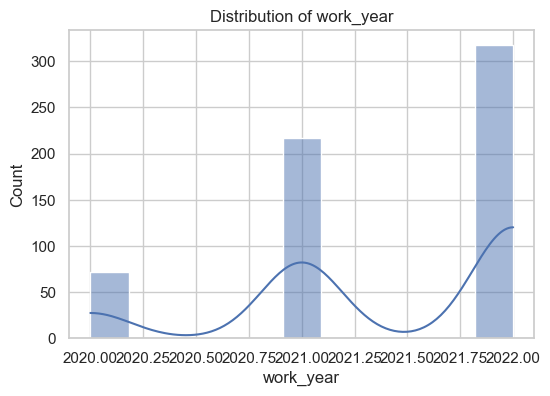

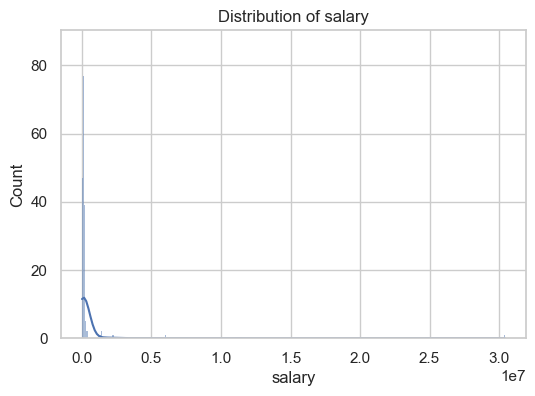

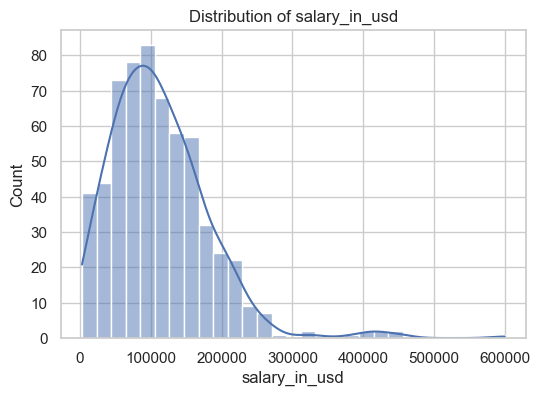

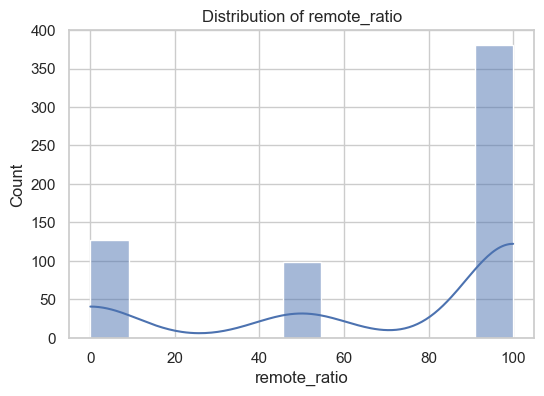

In [100]:
for col in df.select_dtypes(include="number").columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# Other EDA parts

In [101]:
# Example DataFrame

# Define a mapping function
def map_remote_ratio(ratio):
    if ratio == 0:
        return 'On-site'
    elif ratio == 50:
        return 'Hybrid'
    elif ratio == 100:
        return 'Remote'
    else:
        return 'Other'  # For unexpected values
# Apply the function to create the new column
df['remote_job_type'] = df['remote_ratio'].apply(map_remote_ratio)


## Top Skills per Year

In [102]:
top_jobs_per_year = df.groupby(["work_year", "job_title"]).size().reset_index(name='count')
print(top_jobs_per_year.sort_values(['work_year', 'count'], ascending=[True, False]).groupby('work_year').head(5))


    work_year                  job_title  count
10       2020             Data Scientist     21
6        2020              Data Engineer     11
5        2020               Data Analyst      7
16       2020  Machine Learning Engineer      5
2        2020          Big Data Engineer      3
43       2021             Data Scientist     45
38       2021              Data Engineer     32
56       2021  Machine Learning Engineer     18
34       2021               Data Analyst     17
63       2021         Research Scientist     10
77       2022              Data Engineer     89
80       2022             Data Scientist     77
72       2022               Data Analyst     73
91       2022  Machine Learning Engineer     18
76       2022             Data Architect      8


## Year-over-Year Growth

In [103]:
job_counts = df.groupby(['work_year', 'job_title']).size().unstack(fill_value=0)
yoy_growth = job_counts.pct_change().replace([np.inf, -np.inf], np.nan).fillna(0)

In [104]:
yoy_growth

job_title,3D Computer Vision Researcher,AI Scientist,Analytics Engineer,Applied Data Scientist,Applied Machine Learning Scientist,BI Data Analyst,Big Data Architect,Big Data Engineer,Business Data Analyst,Cloud Data Engineer,...,Machine Learning Manager,Machine Learning Scientist,Marketing Data Analyst,NLP Engineer,Principal Data Analyst,Principal Data Engineer,Principal Data Scientist,Product Data Analyst,Research Scientist,Staff Data Scientist
work_year,,,,,,,,,,,,,,,,,,,,,
2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021,0.0,3.0,0.0,0.0,0.0,4.0,0.0,0.666667,-0.5,0.0,...,-1.0,3.00,0.0,0.0,0.0,0.0,4.0,-1.0,4.0,0.0
2022,-1.0,-0.5,0.0,0.5,0.0,-1.0,-1.0,-1.000000,1.0,-1.0,...,0.0,-0.25,-1.0,0.0,0.0,-1.0,-0.8,0.0,-0.6,-1.0


## Salary vs Experience Level

In [105]:
print(df.groupby('experience_level')['salary_in_usd'].describe())

                  count           mean            std      min       25%  \
experience_level                                                           
EN                 88.0   61643.318182   44395.541126   4000.0   27505.0   
EX                 26.0  199392.038462  117071.255697  69741.0  130006.5   
MI                213.0   87996.056338   63901.057478   2859.0   48000.0   
SE                280.0  138617.292857   57691.978337  18907.0  100000.0   

                       50%        75%       max  
experience_level                                 
EN                 56500.0   85425.75  250000.0  
EX                171437.5  233750.00  600000.0  
MI                 76940.0  112000.00  450000.0  
SE                135500.0  170000.00  412000.0  


## Salary vs Remote Ratio

In [106]:
print(df.groupby('remote_ratio')['salary_in_usd'].describe())

              count           mean           std     min      25%       50%  \
remote_ratio                                                                  
0             127.0  106354.622047  67724.540800  2859.0  60000.0   99000.0   
50             99.0   80823.030303  57353.093614  5409.0  50355.0   69999.0   
100           381.0  122457.454068  72710.843718  4000.0  75774.0  115000.0   

                   75%       max  
remote_ratio                      
0             140400.0  450000.0  
50             99851.5  423000.0  
100           160000.0  600000.0  


## Salary by Country

In [107]:
print(df.groupby('employee_residence')['salary_in_usd'].median().sort_values(ascending=False))

employee_residence
MY    200000.0
PR    160000.0
US    138475.0
NZ    125000.0
CH    122346.0
AE    115000.0
SG    104176.5
IQ    100000.0
DZ    100000.0
JE    100000.0
AU     87425.0
BE     85699.0
CA     85000.0
BG     80000.0
DE     79197.0
GB     78526.0
BO     75000.0
AT     74130.0
JP     74000.0
RU     72500.0
IE     71444.0
CZ     69999.0
HK     66022.0
SI     63831.0
NL     62651.0
AR     60000.0
LU     59102.0
FR     57920.0
GR     54957.0
PT     53090.0
RO     51419.0
ES     49461.0
PH     45760.0
HR     45618.0
CN     43331.0
PL     41093.5
CL     40038.0
VN     38400.0
DK     37252.5
IT     36366.5
HU     35997.0
EE     32974.0
TN     31875.0
NG     30000.0
MT     28369.0
RS     25532.0
IN     22124.0
CO     21844.0
BR     21453.5
TR     20171.0
HN     20000.0
MX     18185.0
MD     18000.0
PK     16000.0
UA     13400.0
KE      9272.0
IR      4000.0
Name: salary_in_usd, dtype: float64


## Company Size Analysis

In [108]:
print(df['company_size'].value_counts())

company_size
M    326
L    198
S     83
Name: count, dtype: int64


## Remote Work Trends

In [109]:
print(df.groupby('work_year')['remote_ratio'].value_counts(normalize=True))

work_year  remote_ratio
2020       100             0.500000
           50              0.291667
           0               0.208333
2021       100             0.539171
           50              0.304147
           0               0.156682
2022       100             0.716981
           0               0.245283
           50              0.037736
Name: proportion, dtype: float64


# Data Visualization

## Boxplot (Outliers)

## Distribution plots for numeric columns

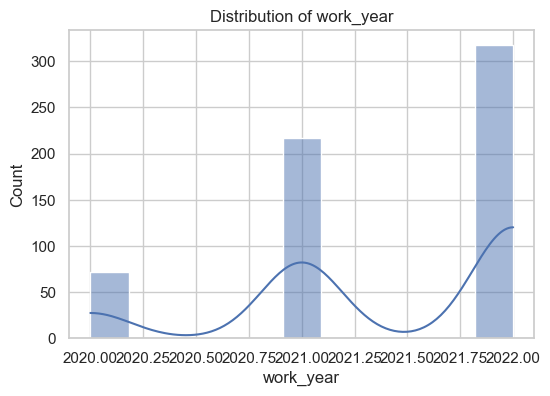

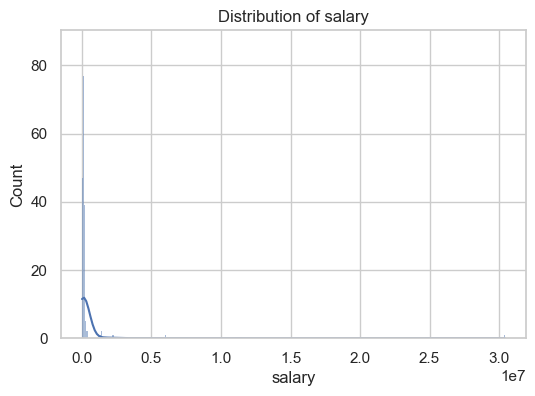

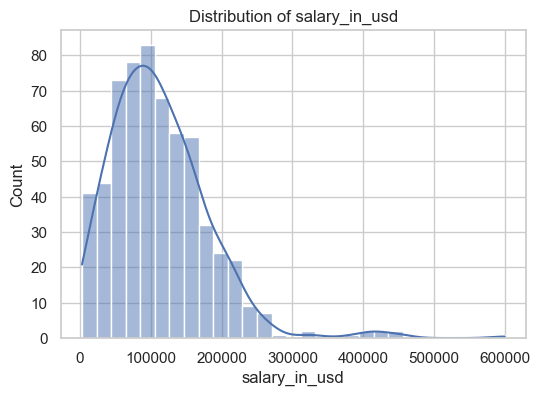

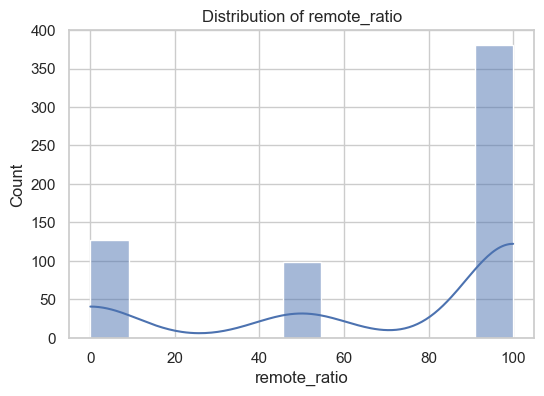

In [110]:
for col in df.select_dtypes(include="number").columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

## Count plots for categorical features

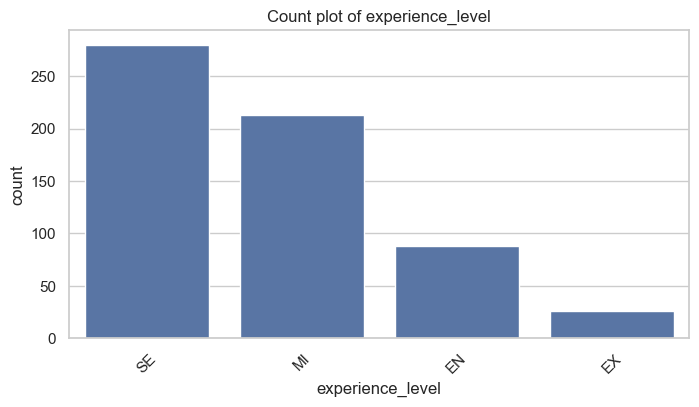

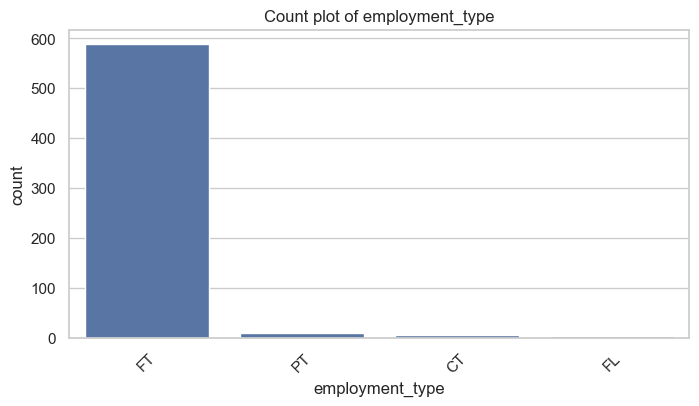

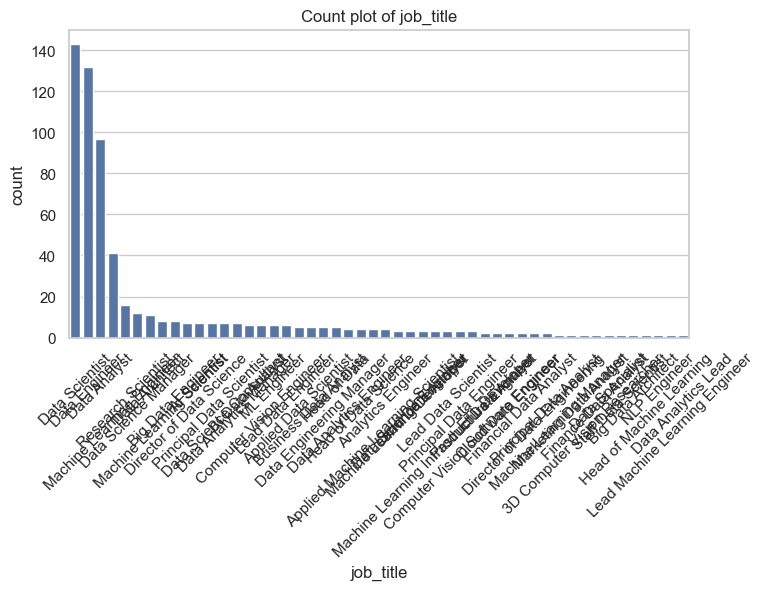

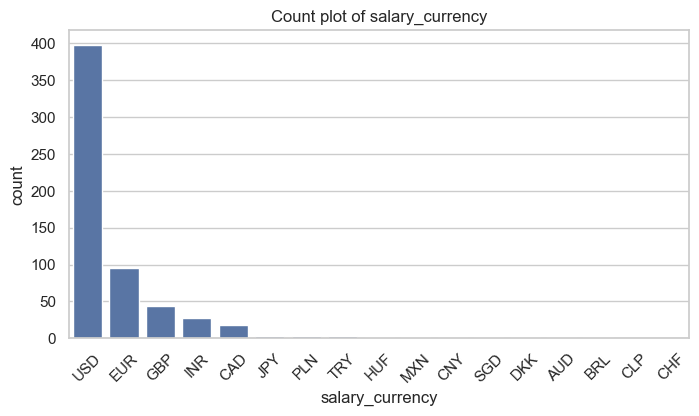

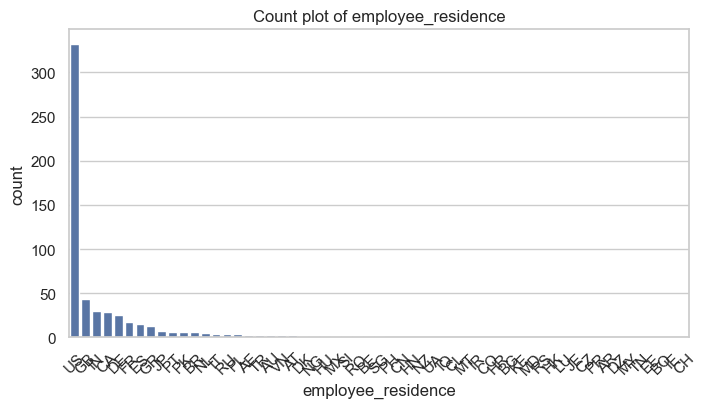

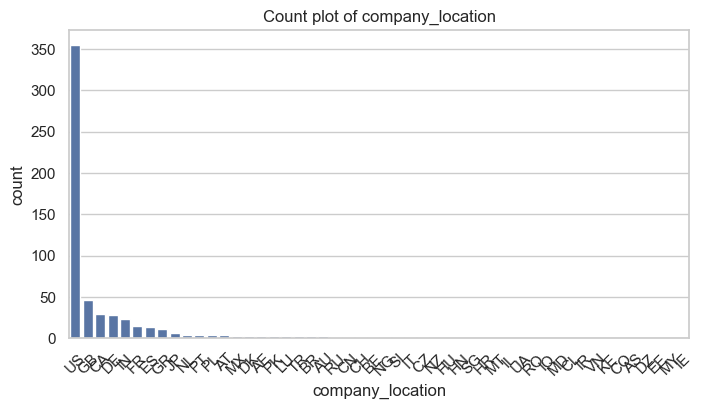

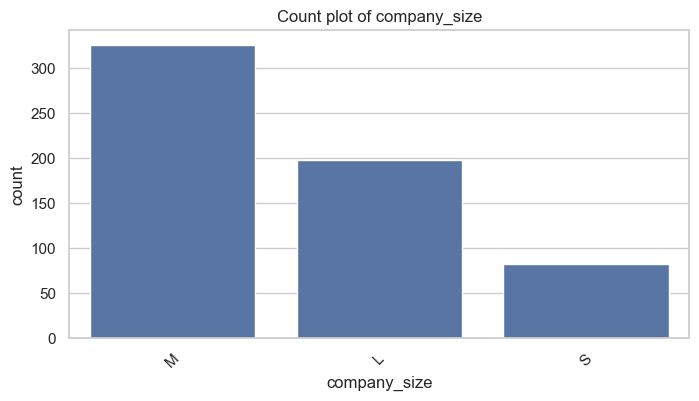

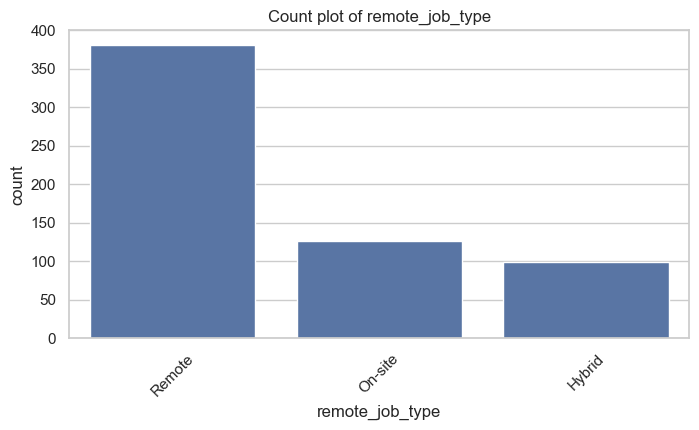

In [111]:
for col in df.select_dtypes(include="object").columns:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f"Count plot of {col}")
    plt.show()

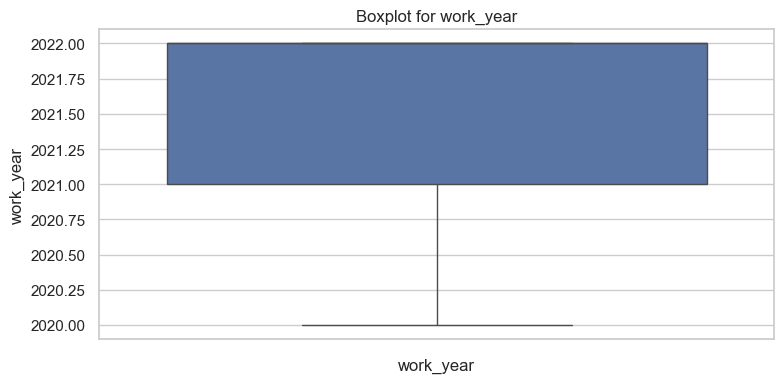

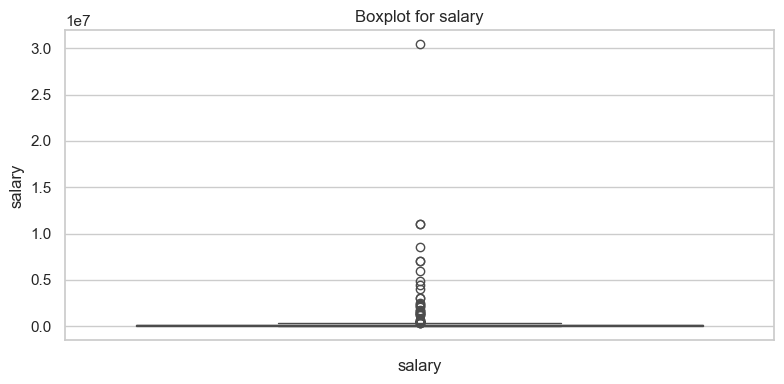

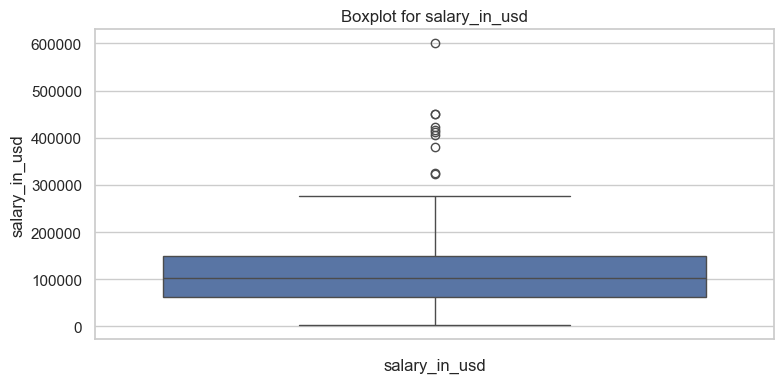

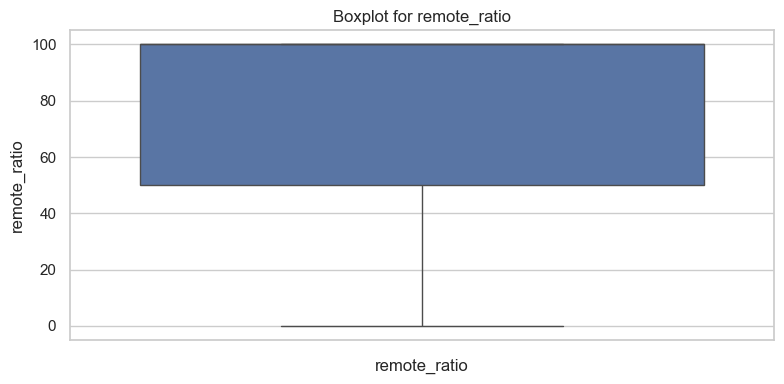

In [112]:
sns.set(style="whitegrid")

for col in df.select_dtypes(include="number").columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(data = df[col])
    plt.title(f'Boxplot for {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

## Heatmap for correlation

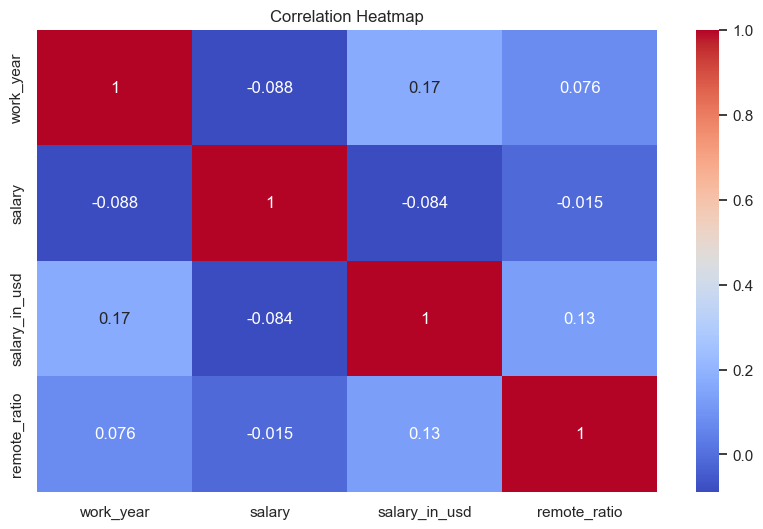

In [113]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Pie chart for skill distribution/job type ratios

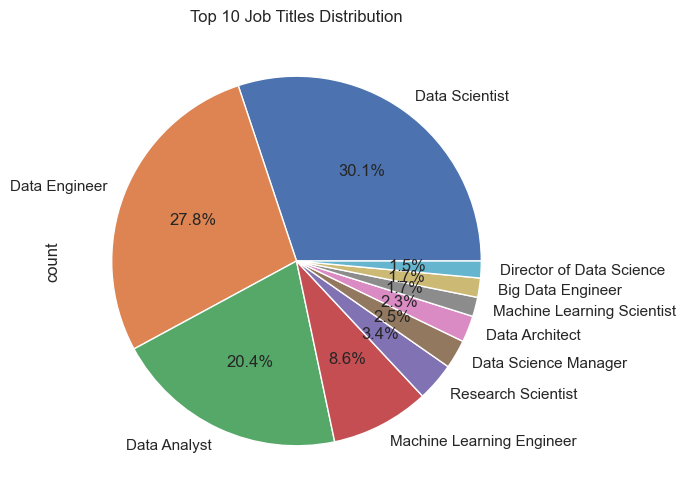

In [114]:
plt.figure(figsize=(6,6))
df["job_title"].value_counts().head(10).plot.pie(autopct="%1.1f%%")
plt.title("Top 10 Job Titles Distribution")
plt.show()

## Time series plots for job trends

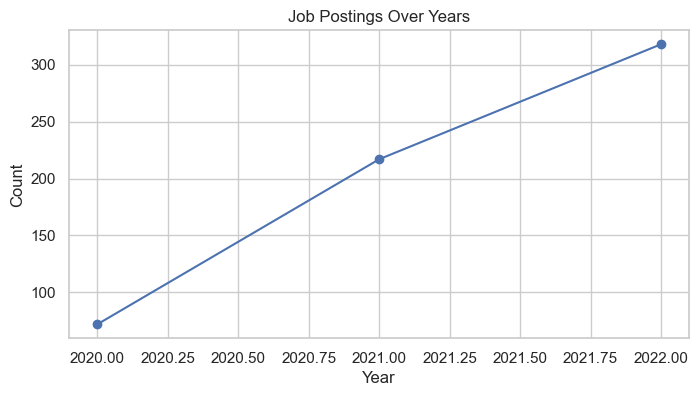

In [115]:
plt.figure(figsize=(8,4))
df["work_year"].value_counts().sort_index().plot(marker='o')
plt.title("Job Postings Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

## Top Skills per Year bar chart

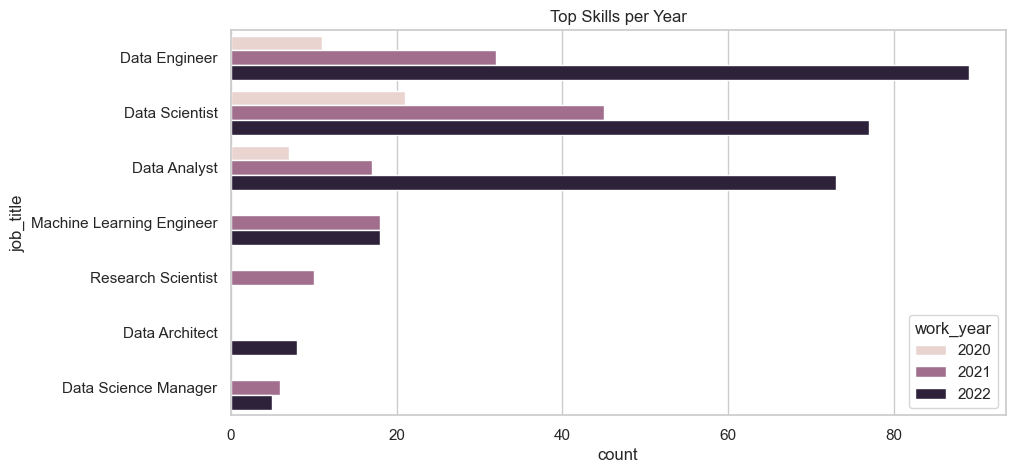

In [116]:
plt.figure(figsize=(10,5))
sns.barplot(data=df.groupby(["work_year", "job_title"]).size().reset_index(name='count').sort_values("count", ascending=False).head(15), x="count", y="job_title", hue="work_year")
plt.title("Top Skills per Year")
plt.show()


## Salary vs Experience Level

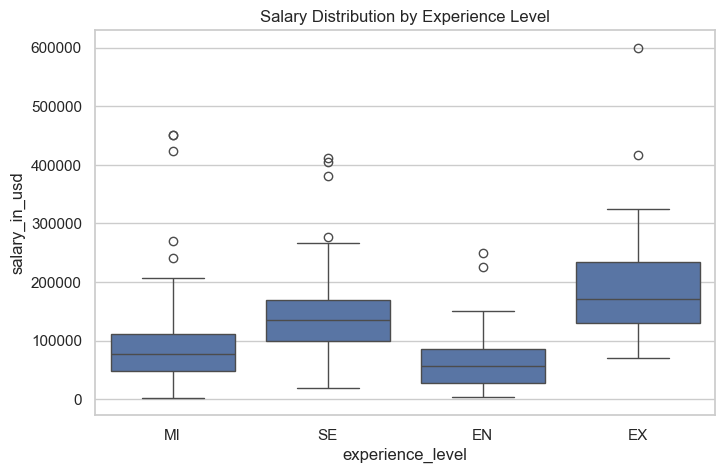

In [117]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="experience_level", y="salary_in_usd")
plt.title("Salary Distribution by Experience Level")
plt.show()

## Salary vs Remote Ratio

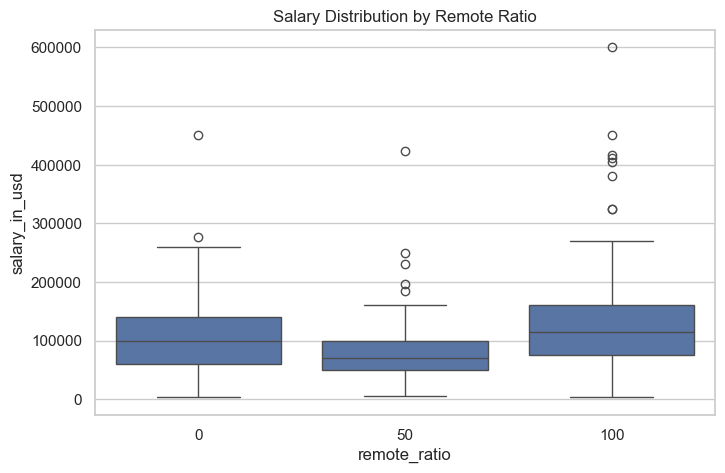

In [118]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="remote_ratio", y="salary_in_usd")
plt.title("Salary Distribution by Remote Ratio")
plt.show()

## Salary by Country

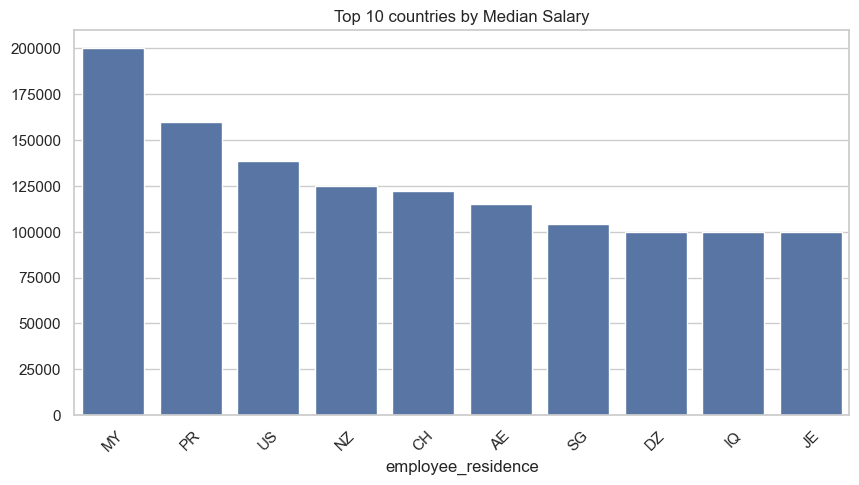

In [119]:
top_countries = df.groupby('employee_residence')['salary_in_usd'].median().nlargest(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.index, y=top_countries.values)
plt.xticks(rotation=45)
plt.title("Top 10 countries by Median Salary")
plt.show()

## Remote Work Trends over years

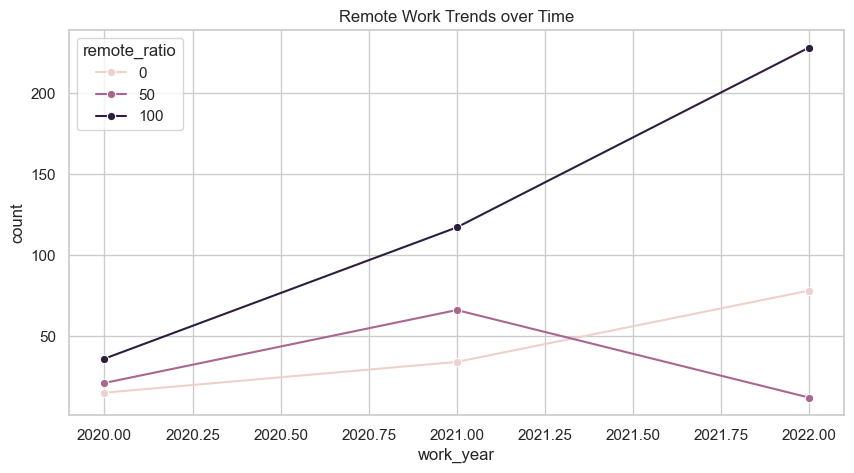

In [120]:
remote_trends = df.groupby(["work_year", "remote_ratio"]).size().reset_index(name="count")
plt.figure(figsize=(10,5))
sns.lineplot(data=remote_trends, x="work_year", y="count", hue="remote_ratio", marker="o")
plt.title("Remote Work Trends over Time")
plt.show()

# Data Preprocessing

## Handling duplicate values

In [121]:
df.drop_duplicates(inplace=True)

## Encoding categorical variables

In [122]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

label_enc = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = label_enc.fit_transform(df[col])

## Normalizing/Scaling numeric data



In [123]:

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns


scaler = StandardScaler()

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [124]:
df["title_word_count"] = df["job_title"].apply(lambda x: len(str(x).split()))

In [125]:
df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,remote_job_type,title_word_count
0,-1.956361,-0.069384,0.028872,0.072596,-0.167734,-1.317605,-0.426180,-1.398455,-1.710815,-1.443945,-1.200344,-0.569918,1
1,-1.956361,0.886756,0.028872,1.839768,-0.048869,0.707794,2.068630,-0.418419,-1.710815,-0.390623,1.787297,-0.569918,1
2,-1.956361,0.886756,0.028872,-1.322539,-0.158350,-1.092560,-0.021966,-1.071776,-0.487257,-1.072184,0.293476,-1.868319,1
3,-1.956361,-0.069384,0.028872,2.397822,-0.199014,0.707794,-1.254701,-0.908437,-1.710815,-0.948264,1.787297,-0.569918,1
4,-1.956361,0.886756,0.028872,1.560741,-0.117686,0.707794,0.545437,0.833850,-0.487257,0.786619,-1.200344,-1.868319,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
602,0.910939,0.886756,0.028872,-0.392449,-0.115183,0.707794,0.600826,0.833850,0.736300,0.786619,0.293476,0.728484,1
603,0.910939,0.886756,0.028872,-0.392449,-0.132700,0.707794,0.213104,0.833850,0.736300,0.786619,0.293476,0.728484,1
604,0.910939,0.886756,0.028872,-0.857494,-0.130823,0.707794,0.254645,0.833850,-1.710815,0.786619,0.293476,-0.569918,1
605,0.910939,0.886756,0.028872,-0.857494,-0.117686,0.707794,0.545437,0.833850,0.736300,0.786619,0.293476,0.728484,1
